In [1]:
import pandas as pd
import os,sys,warnings
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from Bio import SeqIO
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from collections import Counter
from matplotlib.lines import Line2D
import pickle
from skbio.diversity import beta_diversity
from skbio.stats.ordination import pcoa
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from matplotlib.patches import FancyArrowPatch

warnings.filterwarnings("ignore")
os.chdir('/Users/houlin/Desktop/Ecohab/Ecohab22/metatranscriptoms')
path=os.getcwd()
plt.style.use('default')
sys.path.append(os.path.abspath('/Users/houlin/Desktop/Ecohab/Ecohab22/code'))

metadata=pd.read_csv('/Users/houlin/Desktop/Ecohab/Ecohab22/data/Ecohab22_metadata_082324.csv')
metadata1=metadata
metadata=metadata[~metadata['sample-id'].str.contains('EH15|EH16')]

cpl_unfiltered_tax_full=pd.read_csv('CPL/EcoHAB22-CPL-norm-annotated-unfiltered-taxfull.csv',index_col=0)
cpl_filtered_tax_full=pd.read_csv('CPL/EcoHAB22-CPL-norm-annotated-filtered-taxfull.csv',index_col=0)
cpl_clustered_tax_full_filtered=pd.read_csv('CPL/EcoHAB22-CPL-norm-clustered-filtered-taxfull.csv',index_col=0)

df_raw=pd.read_csv('Ecohab22_TPM_annotated-taxfull.csv',index_col=0)
dab_genes=pd.read_excel(f'{path}/dab_genes/dab_genes_v1.xlsx')
nitrogen_genes=pd.read_csv('/Users/houlin/Desktop/Ecohab/Ecohab22/metatranscriptoms/Nitrogen_genes/nitrogen_gene.csv')
df_tax_full=pd.read_csv('Ecohab22_TPM_annotated-filtered-taxfull.csv',index_col=0)

In [252]:
cpl_unfiltered_tax_full=pd.read_csv('CPL/EcoHAB22-CPL-norm-annotated-unfiltered-taxfull.csv',index_col=0)
cpl_filtered_tax_full=pd.read_csv('CPL/EcoHAB22-CPL-norm-annotated-filtered-taxfull.csv',index_col=0)

In [247]:
def sumindex(df,col,percent):
    #percent True or False: if you want to make the results relative abundace to each other
    df=df.dropna(subset=col)
    df_index=df.set_index(col).iloc[:,3:66]
    df_index=rank_by_mean(df_index.groupby(df_index.index).sum())
    if percent:
        df_index=calculate_percentage(df_index)*100
    return df_index

def genename_df(df,genus,db,range_define):
# genus is False-> all, or specify the genus
# db= 'Pfam_description, KO_description,...Pfam, KO
    if not genus:
        df=df
    else:
        df=df[df.LPI_taxonomy.str.contains(genus,na=False)]
    df_dab = df.dropna(subset=['dab_gene'])
    df_ISIP = df.dropna(subset=['ISIP_gene'])
    df_nitrogen = df.dropna(subset=['N_genes'])
    df_sit = df.dropna(subset=['SiLA_gene'])
    if range_define in ['tpm','cpl']:
        df_dab=df_dab.iloc[:,3:66].groupby(df_dab['dab_gene']).sum()
        df_ISIP=df_ISIP.iloc[:,3:66].groupby(df_ISIP['ISIP_gene']).sum()
        df_nitrogen = df_nitrogen.iloc[:,3:66].groupby(df_nitrogen['N_genes']).sum()
        df_sit=df_sit.iloc[:,3:66].groupby(df_sit['SiLA_gene']).sum()
    else:
        df_dab=df_dab.iloc[:,0:63].groupby(df_dab['dab_gene']).sum()
        df_ISIP=df_ISIP.iloc[:,0:63].groupby(df_ISIP['ISIP_gene']).sum()
        df_nitrogen= df_nitrogen.iloc[:,0:63].groupby(df_nitrogen['N_genes']).sum()
        df_sit=df_sit.iloc[:,0:63].groupby(df_sit['SiLA_gene']).sum()

    df_filter=df.dropna(subset=[db])
    df_filter=df_filter[~df_filter[db].str.contains('unknown',case=False)]
    if range_define in ['tpm','cpl']:
        df_pfam=df_filter.iloc[:,3:66].groupby( df_filter[db]).sum()
    else:
        df_pfam=df_filter.iloc[:,0:63].groupby( df_filter[db]).sum()
    df_sum= pd.concat([df_dab, df_ISIP,df_nitrogen,df_sit,df_pfam], axis=0, ignore_index=False)
    return df_sum

def dominated_genes(df):
# Condition 1: Mean of the row is greater than 1
    condition1 = df.mean(axis=1) > 0.05
    # Condition 2: Any column entry in the row is greater than 0.1
    condition2 = df.max(axis=1) > 0.1
    # Combine the conditions
    combined_condition = condition1 | condition2
    # Record the index of the rows that meet either condition
    filtered_indices = df.index[combined_condition]
    return pd.DataFrame(filtered_indices.tolist(),columns=['Genes'])

def rank_by_mean(df):
    df_ranked = df.loc[df.mean(axis=1).sort_values(ascending=False).index]
    return df_ranked
#finding dominanted cells
def dominated_tax(df):
# Condition 1: Mean of the row is greater than 1
    condition1 = df.mean(axis=1) > 1
    # Condition 2: Any column entry in the row is greater than 5
    condition2 = df.max(axis=1) > 5
    # Combine the conditions
    combined_condition = condition1 | condition2
    # Record the index of the rows that meet either condition
    filtered_indices = df.index[combined_condition]
    return pd.DataFrame(filtered_indices.tolist(),columns=['Tax'])

def spearman_corr_pvalues(df):
    rho = pd.DataFrame(np.zeros((df.shape[1], df.shape[1])),
                       columns=df.columns, index=df.columns)
    pval = pd.DataFrame(np.ones((df.shape[1], df.shape[1])),
                        columns=df.columns, index=df.columns)
    for col in df.columns:
        for row in df.columns:
            if col != row:
                valid_idx = df[[col, row]].dropna().index
                rho[col][row], pval[col][row] = spearmanr(df.loc[valid_idx, col], df.loc[valid_idx, row])
            else:
                rho[col][row] = 1.0
                pval[col][row] = np.nan  # For the same variables, we set NaN
    return rho, pval
from scipy.stats import spearmanr

def extract_gene_names(fasta_file):
    gene_names = []
    for record in SeqIO.parse(fasta_file, "fasta"):
        gene_names.append(record.id)
    return gene_names

def calculate_percentage(df):
    # Calculate the sum of each column, axis=0 is column
    column_sums = df.sum(axis=0) 
    # Divide each element by its column sum and multiply by 100 to get percentage
    percentages_df = df.div(column_sums, axis=1) 

    return percentages_df

def normalize_rows(data):
    colnames = data.columns.tolist()
    rownames = data.index.tolist()
    normalized_data = np.zeros_like(data, dtype=float)
    num_rows, num_cols = data.shape
    for i in range(num_rows):
        mean = np.mean(data.iloc[i])
        std = np.std(data.iloc[i])
        normalized_data[i] = (data.iloc[i] - mean) / std
        #normalized_data[i] = (data.iloc[i] - np.min(data.iloc[i])) / (np.max(data.iloc[i])-np.min(data.iloc[i]))
    normalized_data=pd.DataFrame(normalized_data)
    normalized_data.columns=colnames
    normalized_data.index=rownames
    return normalized_data

def averaging_expression(expression,metadata_used,round_num,metadata):
    df_mean=expression
    if metadata_used=='sample-id':
        df_mean_normalized=normalize_rows(df_mean)
    else:
        metadata=metadata.set_index('sample-id')
        if metadata_used in ['Date','group_chl','Phase_group','Geo_group','diatom_group','Eu_group']:
            df_mean.columns=metadata.loc[df_mean.columns,metadata_used]
        elif metadata_used in ['Depth']:
            df_mean.columns=round(metadata.loc[df_mean.columns,metadata_used])
        else:
            df_mean.columns=round(metadata.loc[df_mean.columns,metadata_used],round_num)
        df_mean=df_mean.sort_index(axis=1)
        df_T = df_mean.T
        # Group by the index (original column names) and sum
        df_grouped = df_T.groupby(df_T.index).mean()
        # Transpose back to the original orientation
        df_mean = df_grouped.T
        df_mean_normalized=normalize_rows(df_mean)
    return df_mean, df_mean_normalized

def count_tax(filtered_gene_df):
    #df_l7=gene_df.set_index('L7')
    filtered_gene_df=pd.DataFrame(filtered_gene_df)
    #df_l7=df_l7.iloc[:,3:66] filtering the dataframe to keep only the samples, not NC or PC
    a=pd.DataFrame(filtered_gene_df.sum(axis=1))
    a=a.groupby(a.index).sum()
    totalcount=a.sum()[0]
    a.columns=['counts']
    percent=[x/totalcount for x in a.counts]
    a['percent']=percent

    a.reset_index(drop=False, inplace=True)
    a.columns = ['tax', 'counts', 'percent']
    sorted_a=a.sort_values(by='counts',ascending=False)
    return sorted_a

def jaccard_index(df):
    species = df.columns
    jaccard = pd.DataFrame(index=species, columns=species, dtype=float)
    for i in species:
        for j in species:
            if i != j:
                intersection = np.sum(df[i] & df[j])
                union = np.sum(df[i] | df[j])
                jaccard.loc[i, j] = intersection / union
            else:
                jaccard.loc[i, j] = 1.0
    return jaccard

# Fisher's exact test for significant co-occurrence
def fisher_test(df):
    species_pairs = list(itertools.combinations(df.columns, 2))
    p_values = {}
    for (species1, species2) in species_pairs:
        contingency_table = pd.crosstab(df[species1], df[species2])
        if contingency_table.shape == (2, 2):
            _, p_value = fisher_exact(contingency_table)
            p_values[(species1, species2)] = p_value
    return p_values

def adding_taxes(df,taxlevel,df_match,type): 
    l2names=[]
    l4names=[]
    l3names=[]
    l5names=[]
    l6names=[]
    for taxname in df.Tax:

        condition = df_match.isin([taxname])
        # Locate the rows that contain 'A'
        a = df_match.loc[condition.any(axis=1)]
        l2names.append(a.L2.iloc[0]) 
        l3names.append(a.L3.iloc[0])
        l4names.append(a.L4.iloc[0])
        l5names.append(a.L5.iloc[0])
        l6names.append(a.L6.iloc[0])
    if taxlevel=='L8':
        df['L6']=l6names
        df['L5']=l5names
        df['L4']=l4names
        if type!='Eu':
            df['L3']=l3names
            df['L2']=l2names
    elif taxlevel=='L6':
        if type!='Eu':
            df['L4']=l4names
            df['L3']=l3names
            df['L2']=l2names
        else:
            df['L4']=l4names
            df['L5']=l5names
    elif taxlevel=='L4':
        df['L3']=l3names
        df['L2']=l2names
    elif taxlevel=='L3':
        df['L2']=l2names
    return df

def displaying_upperlevel(df,taxlevel,df_match):
    df_l3=df.loc[:,['mean_corr','mean_pval','corr_tax','frequency',taxlevel]]
    df_results= df_l3.groupby(df_l3[taxlevel]).agg({
    'mean_corr': 'mean',  # Mean of numerical column B
    'mean_pval': 'mean',  # Mean of numerical column C
    'corr_tax': aggregate_strings,  # Concatenate strings in column D
    'frequency':'sum'
    }).reset_index()
    df_results.columns=['Tax','mean_corr','mean_pval','corr_tax','frequency']
    df=df_results.sort_values(by='frequency',ascending=False)
    df_final=adding_taxes(df,taxlevel,df_match,'all')
    return df_final

def clr_transformation_df(df):
    df=df.replace(0,1e-10)
    clr_transformed = clr(df.T)
    # Convert back to a dataframe for easier handling
    clr_df = pd.DataFrame(clr_transformed, index=df.columns, columns=df.index).T
    clr_corr_matrix = clr_df.T.corr(method='corr_method')
    rho,pval=spearman_corr_pvalues(clr_df.T)
    return clr_df,clr_corr_matrix,rho,pval

In [ ]:
cpl_filtered_tax_full.to_csv('CPL/EcoHAB22-CPL-norm-annotated-filtered-taxfull.csv',index=True)

In [13]:
savepath='/Users/houlin/Desktop/Ecohab/Ecohab22/Paper_ISME/Raw_figures'

In [274]:
os.chdir('/Users/houlin/Desktop/Ecohab/Ecohab22/metatranscriptoms')

sil=pd.read_csv('sequence_data/SIT_gene.csv')
sil_dict=dict(map(lambda i,j : (i,j) ,sil.geneID,sil.SIT_gene))
cpl_filtered_tax_full['SiLA_gene']=cpl_filtered_tax_full.index.map(sil_dict)

In [327]:
df=cpl_filtered_tax_full.dropna(subset='dab_gene')
#df=df[df.dab_gene=='dabC']
set(df.MCL_anno)

{'Cytochrome P450',
 'Terpene synthase family 2, C-terminal metal binding',
 'non-haem dioxygenase in morphine synthesis N-terminal'}

In [288]:
df=cpl_filtered_tax_full[cpl_filtered_tax_full.LPI_taxonomy.str.contains('Bacillariophyta',case=False,na=False)]
Counter(df[df.MCL_anno.str.contains('Formamidase',case=False,na=False)].MCL_anno)

Counter({'arylformamidase': 3,
         'N,N-dimethylformamidase beta subunit-like, C-terminal': 1,
         'N,N-dimethylformamidase large subunit': 1})

In [313]:
iron_dict={'flavodoxin I':'Flavodoxin',
           "ferredoxin":'Ferredoxin',
           "ferredoxin, 2Fe-2S":'Ferredoxin',
           "fructose-bisphosphate aldolase, class I":"FBA1",
           'Fructose-bisphosphate aldolase class-II':'FBA2',
           'Fructose-bisphosphate aldolase class-I':'FBA1',
           "Ferric reductase NAD binding domain":'FNR NAD-binding',
           "iron transport multicopper oxidase":"FET3",
           "vacuolar iron transporter family protein":"VIT",
           "Silicon transporter":"SIT",
           "high-affinity iron transporter":"high-affinity FT"
           }

cell_dict={ "programmed cell death protein 4":"PCD4",
    "Thrombospondin type 1 domain":"TSP",
    "zinc transporter, ZIP family":"ZIP family",
    "Copper/zinc superoxide dismutase (SODC)":"SODC",
    "Hsp90 protein":"Hsp90",
    "HEAT SHOCK TRANSCRIPTION FACTOR":"HSTF",
    "heat shock 70kDa protein":"Hsp70",
    "heat shock protein 90kDa beta":"Hsp90",
    "calcium-dependent protein kinase":"CDPKs",
    "Sodium/calcium exchanger protein":"Na/Ca exchanger protein" ,
    "L-ascorbate peroxidase":"L-APX",    
    "glutathione peroxidase":"GPx",
    "glutathione peroxidase activity":"GPx activity",
    "calcium ion binding":"Ca+ binding"
    
}
nitrogen_dict={"GLUTAMINE SYNTHETASE":'GSIIA','glutamine synthetase':'GSIII',
               'GLUTAMATE DEHYDROGENASE':'GDH','glutamate dehydrogenase (NADP+)':'GDH',
               'NAD-specific glutamate dehydrogenase':'GDH','glutamate dehydrogenase':'GDH',
               "ammonium transporter Rh":'AMT Rh','Ammonium Transporter Family':'AMT',
               'glutamate synthase (NADH)':'GOGAT','glutamate synthase activity':'GOGAT',
               'nitrate reductase / nitrite oxidoreductase, beta subunit':'NXR',
               'urea-proton symporter':'UT','solute carrier family 14 (urea transporter)':'UT',
               "Arginase family":'Arg','Ornithine cyclodeaminase/mu-crystallin family':'OCD',
               "ornithine carbamoyltransferase":'OTC',
               "NAD-specific glutamate dehydrogenase":'GDH',
               "urease accessory protein":'Ure',
               "urease":'Ure',
               'MFS transporter, NNP family, nitrate/nitrite transporter':'NRT2',
               'nitrite reductase [NAD(P)H], small subunit':'NAD(P)H-Nir',
               'ferredoxin-nitrite reductase':'Fd-Nir',
               "glutamate N-acetyltransferase / amino-acid N-acetyltransferase":"GACT"}
carbon_dict={"Phosphoglycerate kinase":'PGK',"phosphoglycerate kinase":'PGK',
"Fructose-bisphosphate aldolase class-I":'FBA1',
"Fructose-bisphosphate aldolase class-II":'FBA2',
"fructose-bisphosphate aldolase, class I":'FBA1',
 "ENOLASE (DUF1399)":'enolase',
 "diphosphate-dependent phosphofructokinase":'DPi-PFK',
 "Phosphoenolpyruvate carboxylase":"PEPC",
"PHOSPHOENOLPYRUVATE CARBOXYLASE":"PEPC",
"Phosphoglycerate kinase":"PGK","phosphoglycerate kinase":"PGK",
"phosphoenolpyruvate carboxykinase (ATP)":"PEPCK",
"acetyl-CoA carboxylase / biotin carboxylase 1":"ACCase",
"glyceraldehyde 3-phosphate dehydrogenase (phosphorylating)":"GADPH",
"Photosystem II 12 kDa extrinsic protein (PsbU)":"PsbU",
"photosystem II oxygen-evolving enhancer protein 3":"PsbQ",
"photosystem II P680 reaction center D1 protein":"PsbA",
"photosystem II 22kDa protein":"PsbS",
"photosystem II reaction center protein PsbM":"PsbM",
"Photosystem II Psb31 protein":"Psb31",
"photosystem II P680 reaction center D2 protein":"PsbD",
"Photosystem II Pbs27":"Pbs27",
"photosystem II PsbY protein":"PsbY",
"Photosystem II protein":'PSII',
"Triosephosphate isomerase":'TPI',
"Manganese-stabilising protein / photosystem II polypeptide":"PsbO",
"CHLOROPHYLL A-B BINDING PROTEIN, CHLOROPLASTIC":"Chlorophyll A-B binding protein",
"light-harvesting complex I chlorophyll a/b binding protein 1":"LHCA1",
"ribulose-bisphosphate carboxylase large chain":'RBCL',
"Ribulose bisphosphate carboxylase, small chain":"RBCS",
"Photosystem I psaA/psaB protein":'PsaA/PsaB',
"Copper binding proteins, plastocyanin/azurin family":'plastocyanin/azurin family',
"ferredoxin--NADP+ reductase":"FNR",
"Transaldolase/Fructose-6-phosphate aldolase":"TAL",
    "F-type H+-transporting ATPase subunit beta":"F-ATPase",
    "F-type H+-transporting ATPase subunit alpha":"F-ATPase",
    "HAD ATPase, P-type, family IC":"ATPase activity",
    "V-type H+-transporting ATPase subunit B":"V-ATPase",
    "V-type H+-transporting ATPase subunit A":"V-ATPase",
    "V-type ATPase 116kDa subunit family":"V-ATPase",
    "F-type H+-transporting ATPase subunit d":"F-ATPase",
    "F-type H+-transporting ATPase subunit d":"F-ATPase",
    "F-type H+-transporting ATPase subunit delta":"F-ATPase",
    "V-TYPE PROTON ATPASE 21 KDA PROTEOLIPID SUBUNIT":"V-ATPase",
    "V-ATPase subunit C":"V-ATPase",
    "V-type H+-transporting ATPase subunit E":"V-ATPase",
    "Anion-transporting ATPase":"ATPase activity",
    "F-type H+-transporting ATPase subunit f":"F-ATPase",
    "F-type H+-transporting ATPase subunit c":"F-ATPase",
    "F-type H+-transporting ATPase subunit c":"F-ATPase",
    "Vacuolar (H+)-ATPase G subunit":"V-ATPase",
    "vacuolar proton-transporting V-type ATPase, V1 domain":"V-ATPase",
    "pyruvate carboxylase":"PC",
    "malate dehydrogenase":"MDH",
    "pyruvate kinase":"PK",
    "phosphoribulokinase":"PRK",
    
}
meta_dict={'Nitrogen':nitrogen_dict,'Iron':iron_dict,
           'Carbon':carbon_dict,'Other':cell_dict}


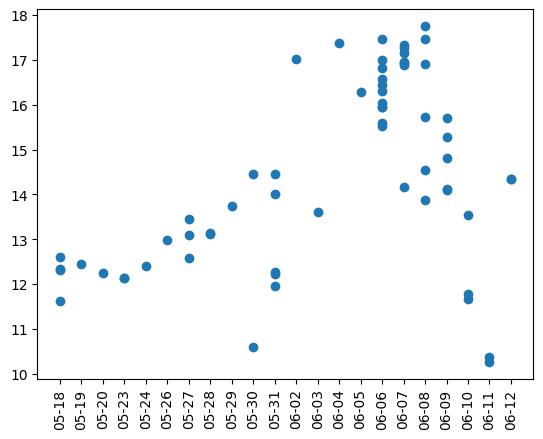

In [243]:
df=metadata.sort_values('Date')
x=df.Date
y=df.Mean_Temp
plt.scatter(x,y)
plt.xticks(rotation=90);

In [215]:
from matplotlib.colors import BoundaryNorm
import re
import json
with open('pfam_genename_dict.txt', 'r') as file:
    pfam_genename_dict = json.load(file)

In [316]:
nitrogen_set=['nitrogen_gene',"ammoninum_assimilation",'urea_cycle']
iron_set=['iron_uptake','low_iron','silicon']
carbon_set=["carbon_cycle","photosynthesis",'energy']
other_set=["dab_gene","stress_related","calcium"]
genedict={'Nitrogen':nitrogen_set,'Iron':iron_set,
          'Carbon':carbon_set,'Other':other_set}

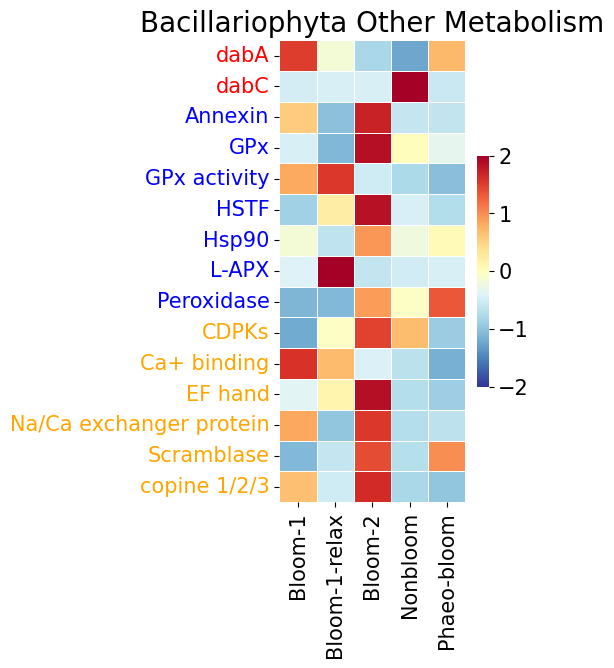

In [320]:
from matplotlib.colors import BoundaryNorm
import re
import json
with open('pfam_genename_dict.txt', 'r') as file:
    pfam_genename_dict = json.load(file)
pfam_genename_dict.keys()
order=['Bloom-1','Bloom-1-relax','Nonbloom','Bloom-2','Phaeo-bloom']
##################### initalize Dataframe ############################################################
db=pfam_genename_dict
df=cpl_filtered_tax_full

tax_name='Bacillariophyta'
dataused='Phase_group'
metabolisom='Other'
name=f'{tax_name} {metabolisom} Metabolism'

cpl_df=genename_df(df,tax_name,'MCL_anno','cpl') #'Bacillariophyta' 'Mamiellophycea'
cpl_df=cpl_df.drop(index=['GSIIA','GSIII','NRT2','Low iron-inducible periplasmic protein','NirB','NirG'])
cpl_df_relative=calculate_percentage(cpl_df)*100

genelist=genedict[metabolisom]
gene_used = set(g for x in genedict[metabolisom] for g in db[x])
pattern="|".join(re.escape(item) for item in gene_used)
Pfam_filtered = cpl_df_relative[cpl_df_relative.index.str.contains(pattern, case=True)]

set1=set(Pfam_filtered.index)
set2=set(gene_used)
use=list(set1.intersection(set2))
    
colorc=['red','blue','orange','black','black']
def setcolor(g,heatmap,genelist):
    for label in g.ax_heatmap.get_yticklabels() if heatmap else g.get_yticklabels():
        x=label.get_text()
        for i in range(len(genelist)):
            if x in db[genelist[i]]:
                label.set_color(colorc[i])

##################### Average across group ############################################################
dfv_mean,dfv_norm=averaging_expression(Pfam_filtered.loc[use],dataused,2,metadata) #.loc[use]
dfv_norm=dfv_norm.dropna()
df=dfv_norm

##################### change the df index and orders ############################################################
df=df.rename(index=meta_dict[metabolisom])

df = df.groupby(df.index).mean()
use=[]
for i in range(len(genelist)):
    for x in df.index:
        if x in db[genelist[i]]:
            use.append(x)
df=df.loc[use]

##################### Set Boundaries############################################################
boundaries = [0,0.0025,0.005,0.01, 0.02,0.03, 0.04,0.05 ,0.06, 0.08, 0.1, 0.2,0.25,0.3, 0.35, 0.4]
norm = BoundaryNorm(boundaries, ncolors=256)

boundaries= [0,0.01,0.02,0.03,0.04 ,0.05,0.08 ,0.1,0.3, 0.4, 0.5, 0.6, 0.65]
norm_iron = BoundaryNorm(boundaries, ncolors=256)

boundaries= [0,5e6, 1e7, 2e7, 5e7, 8e7, 1e8, 2e8, 3e8, 4e8]
norm_iron1 = BoundaryNorm(boundaries, ncolors=256)

boundaries= [0,0.05,0.1, 0.2, 0.4, 0.6, 0.8, 1, 1.5, 4]
norm1 = BoundaryNorm(boundaries, ncolors=256)

##################### normal heat map ############################################################

plt.style.use('default')

fig=plt.figure(figsize=(3,6)) 
if dataused=='sample-id':
    metadata_sample=metadata.set_index('sample-id')
    df.columns=metadata_sample.loc[df.columns.tolist(),'Date']
    df_plot=df.sort_index(axis=1)
    df_cleaned = df_plot.drop(columns=[col for col in df_plot.columns if pd.isna(col)])
orig_map=plt.cm.get_cmap("RdYlBu") 
g=sns.heatmap(df,#norm=norm,
              cmap=orig_map.reversed(), fmt=".1f", linewidths=.5,
              vmin=-2, vmax=2,cbar_kws={'shrink': 0.5} )
cbar = g.collections[0].colorbar
cbar.ax.tick_params(labelsize=15) 
setcolor(g,False,genelist)
plt.title(name,fontsize=20)
plt.xticks(rotation=90,fontsize=15)
plt.yticks(fontsize=15)
fig.savefig(f'{savepath}/diatom/diatom_{metabolisom}_heatmap.svg',dpi=500,bbox_inches='tight')
plt.show()


# ##################### Braycurtis Distance Matrix clustering ############################################################
# dist_matrix = pdist(df.T, metric='braycurtis') # braycurtis, Euclidean
# linkage_matrix = linkage(dist_matrix, method='weighted') # ward, weighted, average, centroid, median

# plt.style.use('default')
# plt.figure(figsize=(5, 3))
# dendrogram(linkage_matrix, labels=df.columns, leaf_rotation=90)
# plt.title(name,fontsize=15)
# plt.xlabel(dataused)
# plt.xticks(fontsize=12)
# plt.ylabel('Bray-Curtis Distance',fontsize=15)
# plt.show()

# ##################### heatmap with Braycurtis Distance Matrix clustering ###############################################
# sns.set_theme(font_scale=1.5)
# g=sns.clustermap(df, cmap="vlag",#norm=norm, 
#                  figsize=(10,12), linewidths=.5, col_linkage=linkage_matrix,
#                  cbar_kws={'shrink': 0.1, 'label': 'DESeq Normalized Expression'})
# setcolor(g,True) 
# g.figure.subplots_adjust(top=0.93)
# g.figure.suptitle(name,fontsize=20)
# g.cax.set_position([0.05, 0.8, 0.02, 0.2]) 
# g.tick_params(axis='x', labelsize=20, rotation=90)
# g.tick_params(axis='y', labelsize=20)
# # Display the plot
# plt.show(g)



In [282]:
dfv_mean.mean(axis=1)*1000

ISIP1                                             12.554894
SiLA26                                             0.938955
SiLA35                                            10.447254
Multicopper oxidase                               18.246358
high-affinity iron transporter                    25.744778
flavodoxin I                                     230.197477
Ferric reductase NAD binding domain                0.790839
plastocyanin                                     103.550562
ISIP2A                                           172.519053
SiLA12                                             0.233983
SiLA44                                             2.047657
ferredoxin                                        12.957170
Ferric reductase like transmembrane component      0.000000
Flavodoxin                                         0.981520
vacuolar iron transporter family protein           4.524335
iron transport multicopper oxidase               188.961242
Silicon transporter                     

In [272]:
df=cpl_unfiltered_tax_full
df=sumindex(df,'dab_gene',False)
df.mean(axis=1)

dab_gene
dabC    2.902191e+06
dabA    2.664726e+06
dabD    6.440399e+04
dabB    2.454350e+04
dtype: float64

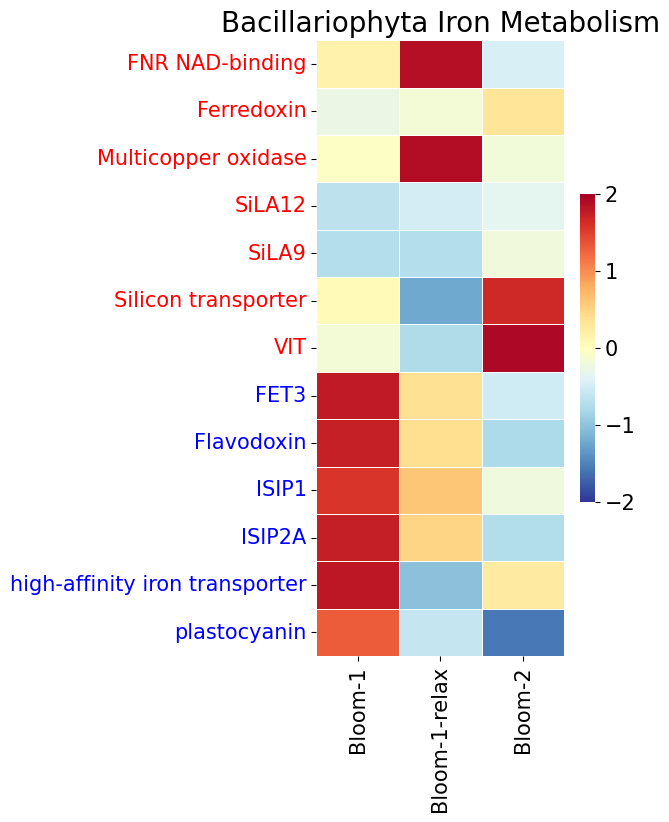

In [266]:
plt.style.use('default')

fig=plt.figure(figsize=(4,8)) 
if dataused=='sample-id':
    metadata_sample=metadata.set_index('sample-id')
    df.columns=metadata_sample.loc[df.columns.tolist(),'Date']
    df_plot=df.sort_index(axis=1)
    df_cleaned = df_plot.drop(columns=[col for col in df_plot.columns if pd.isna(col)])
orig_map=plt.cm.get_cmap("RdYlBu") 

g=sns.heatmap(df,#norm=norm,
              cmap=orig_map.reversed(), fmt=".1f", linewidths=.5,
              vmin=-2, vmax=2,cbar_kws={'shrink': 0.5} )
cbar = g.collections[0].colorbar
cbar.ax.tick_params(labelsize=15) 
setcolor(g,False,genelist)
plt.title(name,fontsize=20)
plt.xticks(rotation=90,fontsize=15)
plt.yticks(fontsize=15)
fig.savefig(f'{savepath}/diatom_{metabolisom}_heatmap.svg',dpi=500,bbox_inches='tight')
plt.show()

In [119]:
df=cpl_filtered_tax_full
df=df[~df.KO.isna()]
df=sumindex(df,'KO',True)
df